# K-NN, SVM et SVR

Dans ce notebook, on étudie un problème de **classification** et un problème de **régression** sur un jeu de données médical lié au risque cardiovasculaire.

Les objectifs sont :
- prédire `Heart_Disease_Risk` en classification ;
- prédire `Cholesterol_LDL` en régression.

Trois méthodes vues en cours sont comparées :
- le **kNN** ;
- le **SVM** ;
- le **SVR**.

L’accent est mis sur une démarche propre :
- séparation claire entre entraînement, validation et test ;
- optimisation des hyperparamètres uniquement sur le train ;
- utilisation de `Pipeline` sklearn pour éviter les fuites d’information ;
- comparaison finale des modèles optimisés.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold, train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', None)

In [2]:
project_dir = Path.cwd()
if not (project_dir / 'divers').exists():
    project_dir = project_dir.parent

data_path = project_dir / 'divers' / 'healthcare_synthetic_data.csv'
data = pd.read_csv(data_path)
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


## 3. Préprocessing

On sépare les variables :
- **catégorielles** : `Gender`, `Smoking_Status`, `Alcohol_Consumption`, `Physical_Activity_Level`, `Family_History` ;
- **numériques** : les autres variables cliniques.

Le préprocessing est intégré dans des **Pipeline** avec :
- `OneHotEncoder` pour les variables qualitatives ;
- `StandardScaler` pour les variables numériques.

Ainsi, l'encodage et la standardisation sont appris **uniquement sur le train** à l'intérieur des procédures de validation croisée.

In [3]:
categorical_cols = ['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History']
classification_target = 'Heart_Disease_Risk'
regression_target = 'Cholesterol_LDL'

classification_features = [c for c in data.columns if c not in ['Patient_ID', classification_target]]
regression_features = [c for c in data.columns if c not in ['Patient_ID', regression_target, classification_target]]

X_class = data[classification_features].copy()
y_class = data[classification_target].astype(int)

X_reg = data[regression_features].copy()
y_reg = data[regression_target].copy()

numeric_cols_class = [c for c in classification_features if c not in categorical_cols]
numeric_cols_reg = [c for c in regression_features if c not in categorical_cols]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.25,
    random_state=42,
    stratify=y_class,
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42,
)

preprocessor_class = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_class),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ]
)

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_reg),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ]
)

cv_class = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_reg = KFold(n_splits=3, shuffle=True, random_state=42)

print('Classification - train/test :', Xc_train.shape, Xc_test.shape)
print('Régression - train/test :', Xr_train.shape, Xr_test.shape)

Classification - train/test : (11250, 17) (3750, 17)
Régression - train/test : (11250, 16) (3750, 16)


In [4]:
scaling_comparison = []

knn_no_scale = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', 'passthrough', numeric_cols_class),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ])),
    ('model', KNeighborsClassifier(n_neighbors=21))
])

knn_scale = Pipeline([
    ('preprocessor', preprocessor_class),
    ('model', KNeighborsClassifier(n_neighbors=21))
])

svm_no_scale = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', 'passthrough', numeric_cols_class),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ])),
    ('model', SVC(kernel='linear', C=1))
])

svm_scale = Pipeline([
    ('preprocessor', preprocessor_class),
    ('model', SVC(kernel='linear', C=1))
])

for name, model in [
    ('kNN sans scaling', knn_no_scale),
    ('kNN avec scaling', knn_scale),
    ('SVM sans scaling', svm_no_scale),
    ('SVM avec scaling', svm_scale),
]:
    scores = cross_val_score(model, Xc_train, yc_train, cv=cv_class, scoring='balanced_accuracy', n_jobs=-1)
    scaling_comparison.append({
        'Modèle': name,
        'Balanced accuracy CV moyenne': round(scores.mean(), 4),
        'Écart-type CV': round(scores.std(), 4),
    })

pd.DataFrame(scaling_comparison)

,Modèle,Balanced accuracy CV moyenne,Écart-type CV
0,kNN sans scaling,0.5896,0.0060
1,kNN avec scaling,0.6426,0.0123
2,SVM sans scaling,0.7246,0.0092
3,SVM avec scaling,0.7208,0.0097


Ce tableau montre l'effet du scaling **sans utiliser le test**. C'est une comparaison propre : on raisonne uniquement à partir de la validation croisée sur le train. On doit en particulier s'attendre à une amélioration nette pour le kNN, car la distance euclidienne est directement sensible aux unités de mesure.

## 4. Partie classification : `Heart_Disease_Risk`

### 4.1 kNN classification

Le kNN classe une observation en regardant ses plus proches voisins. Le paramètre `k` règle le compromis biais / variance :
- petit `k` : frontière très flexible, variance forte ;
- grand `k` : frontière plus lisse, biais plus élevé.

On sélectionne ici `n_neighbors`, `weights` et `metric` par **GridSearchCV sur le train uniquement**.

In [5]:
knn_clf_pipe = Pipeline([
    ('preprocessor', preprocessor_class),
    ('model', KNeighborsClassifier())
])

knn_clf_grid = {
    'model__n_neighbors': [3, 5, 9, 15, 21],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan'],
}

start = time.perf_counter()
knn_clf_search = GridSearchCV(
    knn_clf_pipe,
    knn_clf_grid,
    cv=cv_class,
    scoring='balanced_accuracy',
    n_jobs=-1,
    return_train_score=True,
)
knn_clf_search.fit(Xc_train, yc_train)
knn_clf_time = time.perf_counter() - start

print('Meilleurs hyperparamètres kNN classification :', knn_clf_search.best_params_)
print('Balanced accuracy CV :', round(knn_clf_search.best_score_, 4))
print('Temps de recherche (s) :', round(knn_clf_time, 2))

Meilleurs hyperparamètres kNN classification : {'model__metric': 'manhattan', 'model__n_neighbors': 21, 'model__weights': 'distance'}
Balanced accuracy CV : 0.6581
Temps de recherche (s) : 13.87


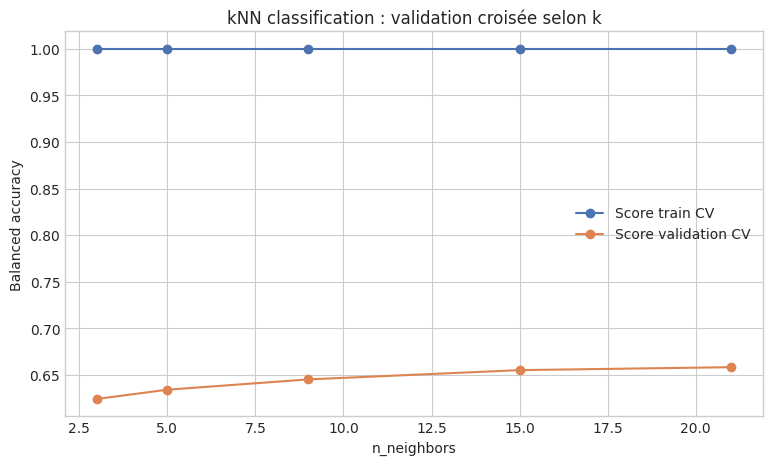

,k,Score train CV,Score validation CV
11,3,1.0,0.623946
13,5,1.0,0.633868
15,9,1.0,0.644934
17,15,1.0,0.654906
19,21,1.0,0.658069


In [6]:
knn_clf_results = pd.DataFrame(knn_clf_search.cv_results_)
knn_clf_curve = knn_clf_results[
    (knn_clf_results['param_model__weights'] == knn_clf_search.best_params_['model__weights'])
    & (knn_clf_results['param_model__metric'] == knn_clf_search.best_params_['model__metric'])
].sort_values('param_model__n_neighbors')

plt.figure(figsize=(9, 5))
plt.plot(knn_clf_curve['param_model__n_neighbors'].astype(int), knn_clf_curve['mean_train_score'], marker='o', label='Score train CV')
plt.plot(knn_clf_curve['param_model__n_neighbors'].astype(int), knn_clf_curve['mean_test_score'], marker='o', label='Score validation CV')
plt.xlabel('n_neighbors')
plt.ylabel('Balanced accuracy')
plt.title('kNN classification : validation croisée selon k')
plt.legend()
plt.show()

knn_clf_curve[['param_model__n_neighbors', 'mean_train_score', 'mean_test_score']].rename(columns={
    'param_model__n_neighbors': 'k',
    'mean_train_score': 'Score train CV',
    'mean_test_score': 'Score validation CV',
})

La lecture de cette courbe demande un peu de prudence. Ici, le score d'entraînement reste égal à 1 pour toutes les valeurs de `k` car le meilleur modèle utilise une pondération par la distance (`weights='distance'`) : chaque observation du train est alors son propre plus proche voisin, ce qui conduit à une classification parfaite sur l'échantillon d'apprentissage. La courbe la plus informative est donc celle de validation croisée. On observe qu'elle progresse légèrement quand `k` augmente, ce qui suggère qu'un voisinage un peu plus large améliore la généralisation en réduisant la variance du modèle. Cela reste cohérent avec le compromis biais/variance vu en cours : des `k` trop petits rendent le modèle très sensible aux fluctuations locales, tandis que des `k` plus grands lissent davantage la frontière de décision.


### 4.2 SVM classification

Le SVM cherche un hyperplan séparateur à **marge maximale**. En pratique :
- `C` contrôle le compromis entre largeur de marge et erreurs tolérées ;
- avec un noyau **RBF**, `gamma` contrôle la flexibilité locale de la frontière ;
- un noyau trop flexible peut produire un surapprentissage, visible par un écart important entre score train et score de validation.

On compare ici un **SVM linéaire** et un **SVM RBF** dans un même `GridSearchCV`.

In [7]:
svc_pipe = Pipeline([
    ('preprocessor', preprocessor_class),
    ('model', SVC())
])

svc_grid = [
    {
        'model__kernel': ['linear'],
        'model__C': [0.1, 0.5, 1, 2],
    },
    {
        'model__kernel': ['rbf'],
        'model__C': [0.5, 1, 2],
        'model__gamma': ['scale', 0.01, 0.1],
    },
]

start = time.perf_counter()
svc_search = GridSearchCV(
    svc_pipe,
    svc_grid,
    cv=cv_class,
    scoring='balanced_accuracy',
    n_jobs=-1,
    return_train_score=True,
)
svc_search.fit(Xc_train, yc_train)
svc_time = time.perf_counter() - start

print('Meilleurs hyperparamètres SVM :', svc_search.best_params_)
print('Balanced accuracy CV :', round(svc_search.best_score_, 4))
print('Temps de recherche (s) :', round(svc_time, 2))

Meilleurs hyperparamètres SVM : {'model__C': 1, 'model__kernel': 'linear'}
Balanced accuracy CV : 0.7208
Temps de recherche (s) : 44.44


In [8]:
svc_results = pd.DataFrame(svc_search.cv_results_)
svc_top = svc_results[['param_model__kernel', 'param_model__C', 'param_model__gamma', 'mean_train_score', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head(8)
svc_top

,param_model__kernel,param_model__C,param_model__gamma,mean_train_score,mean_test_score,rank_test_score
2,linear,1.0,NaN,0.723974,0.720793,1
3,linear,2.0,NaN,0.724305,0.720603,2
1,linear,0.5,NaN,0.723956,0.720589,3
0,linear,0.1,NaN,0.723221,0.720242,4
4,rbf,0.5,scale,0.746049,0.718263,5
7,rbf,1.0,scale,0.758311,0.717781,6
6,rbf,0.5,0.1,0.758027,0.716063,7
11,rbf,2.0,0.01,0.722435,0.715704,8


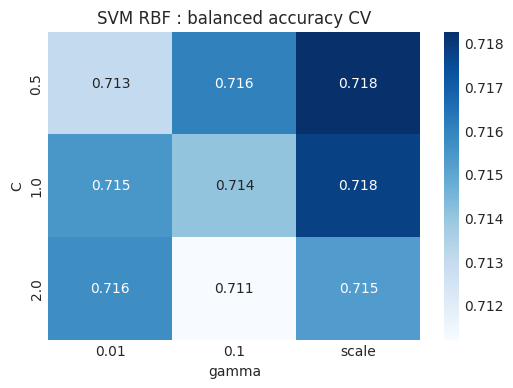

In [10]:
svc_rbf = svc_results[svc_results['param_model__kernel'] == 'rbf'].copy()
if not svc_rbf.empty:
    rbf_pivot = svc_rbf.pivot_table(
        index='param_model__C',
        columns='param_model__gamma',
        values='mean_test_score'
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(rbf_pivot, annot=True, fmt='.3f', cmap='Blues')
    plt.title('SVM RBF : balanced accuracy CV')
    plt.xlabel('gamma')
    plt.ylabel('C')
    plt.show()

Le tableau et la heatmap permettent d'interpréter les hyperparamètres :
- si le meilleur modèle est **linéaire**, cela signifie que la structure globale des données est déjà assez bien séparée dans l'espace transformé ;
- si un modèle **RBF** domine, cela suggère une frontière plus non linéaire ;
- un score train très supérieur au score CV pour certains couples (`C`, `gamma`) est un signe classique de surapprentissage.

In [11]:
classification_models = {
    'kNN classification': knn_clf_search.best_estimator_,
    'SVM classification': svc_search.best_estimator_,
}

classification_results = []
for name, model in classification_models.items():
    y_pred = model.predict(Xc_test)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(Xc_test)[:, 1]
    else:
        y_score = model.decision_function(Xc_test)
    classification_results.append({
        'Modèle': name,
        'Accuracy': round(accuracy_score(yc_test, y_pred), 4),
        'Balanced accuracy': round(balanced_accuracy_score(yc_test, y_pred), 4),
        'F1-score': round(f1_score(yc_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(yc_test, y_score), 4),
    })

classification_results = pd.DataFrame(classification_results).sort_values('Balanced accuracy', ascending=False)
classification_results

,Modèle,Accuracy,Balanced accuracy,F1-score,ROC-AUC
1,SVM classification,0.7237,0.7120,0.6619,0.7937
0,kNN classification,0.6837,0.6619,0.5755,0.7387


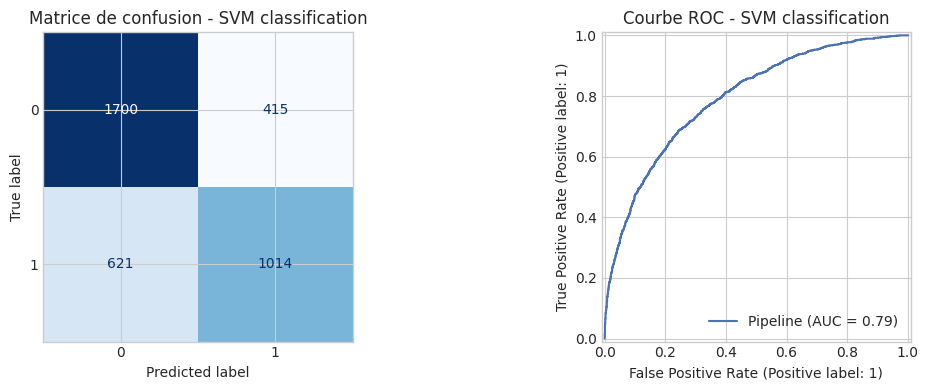

In [12]:
best_clf_name = classification_results.iloc[0]['Modèle']
best_clf = classification_models[best_clf_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(best_clf, Xc_test, yc_test, cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title(f'Matrice de confusion - {best_clf_name}')

RocCurveDisplay.from_estimator(best_clf, Xc_test, yc_test, ax=axes[1])
axes[1].set_title(f'Courbe ROC - {best_clf_name}')
plt.tight_layout()
plt.show()

### Lecture des résultats de classification

La comparaison finale ne regarde le **test** qu'après le tuning. On peut alors commenter proprement :
- le meilleur compromis entre rappel global des classes et précision est donné par le modèle ayant la meilleure **balanced accuracy** et un bon **F1-score** ;
- si le meilleur SVM est linéaire, cela indique que la séparation principale n'a pas besoin d'un noyau très flexible ;
- si le meilleur kNN utilise un `k` assez grand, cela va dans le sens d'un voisinage lissé, donc d'une variance plus faible.

## 5. Partie régression : `Cholesterol_LDL`

Dans cette seconde tâche, la cible devient `Cholesterol_LDL`, et `Heart_Disease_Risk` est retirée des variables explicatives. Les métriques de comparaison sont adaptées à la régression :
- **RMSE** ;
- **MAE** ;
- **R²**.

### 5.1 kNN régression

Le kNN de régression prédit une moyenne locale des voisins. Comme en classification, le choix de `k` gouverne le compromis biais / variance.

In [13]:
knn_reg_pipe = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', KNeighborsRegressor())
])

knn_reg_grid = {
    'model__n_neighbors': [3, 5, 9, 15, 21],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan'],
}

start = time.perf_counter()
knn_reg_search = GridSearchCV(
    knn_reg_pipe,
    knn_reg_grid,
    cv=cv_reg,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    return_train_score=True,
)
knn_reg_search.fit(Xr_train, yr_train)
knn_reg_time = time.perf_counter() - start

print('Meilleurs hyperparamètres kNN régression :', knn_reg_search.best_params_)
print('RMSE CV :', round(-knn_reg_search.best_score_, 4))
print('Temps de recherche (s) :', round(knn_reg_time, 2))

Meilleurs hyperparamètres kNN régression : {'model__metric': 'euclidean', 'model__n_neighbors': 21, 'model__weights': 'distance'}
RMSE CV : 11.7374
Temps de recherche (s) : 16.64


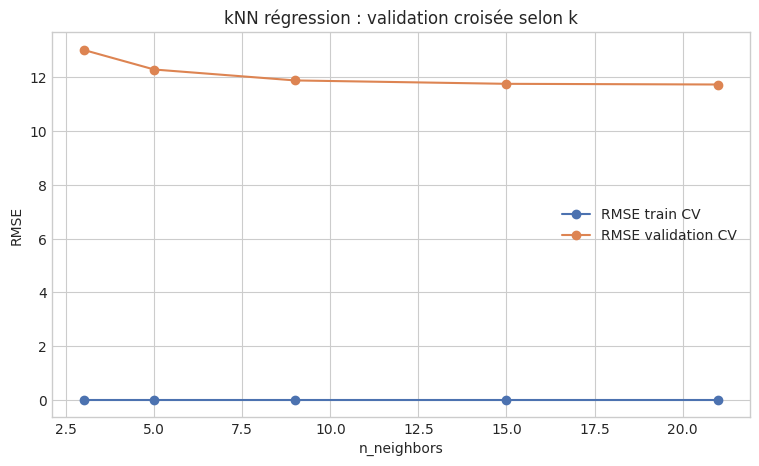

,k,Score train CV,Score validation CV
1,3,-4.983432e-07,-13.023321
3,5,-8.625038e-07,-12.295016
5,9,-1.540407e-06,-11.888776
7,15,-2.538550e-06,-11.762561
9,21,-3.511107e-06,-11.737386


In [14]:
knn_reg_results = pd.DataFrame(knn_reg_search.cv_results_)
knn_reg_curve = knn_reg_results[
    (knn_reg_results['param_model__weights'] == knn_reg_search.best_params_['model__weights'])
    & (knn_reg_results['param_model__metric'] == knn_reg_search.best_params_['model__metric'])
].sort_values('param_model__n_neighbors')

plt.figure(figsize=(9, 5))
plt.plot(knn_reg_curve['param_model__n_neighbors'].astype(int), -knn_reg_curve['mean_train_score'], marker='o', label='RMSE train CV')
plt.plot(knn_reg_curve['param_model__n_neighbors'].astype(int), -knn_reg_curve['mean_test_score'], marker='o', label='RMSE validation CV')
plt.xlabel('n_neighbors')
plt.ylabel('RMSE')
plt.title('kNN régression : validation croisée selon k')
plt.legend()
plt.show()

knn_reg_curve[['param_model__n_neighbors', 'mean_train_score', 'mean_test_score']].rename(columns={
    'param_model__n_neighbors': 'k',
    'mean_train_score': 'Score train CV',
    'mean_test_score': 'Score validation CV',
})

Le score d'entraînement est ici presque nul en RMSE pour toutes les valeurs de `k`. Cela s'explique par le fait que le meilleur modèle utilise une pondération par la distance (`weights='distance'`) : chaque observation d'entraînement est alors son propre plus proche voisin, ce qui conduit à une prédiction presque parfaite sur le train. La courbe la plus informative est donc celle de validation croisée. On observe qu'un voisinage trop petit conduit à une moins bonne généralisation, tandis que des valeurs plus élevées de `k` stabilisent les prédictions et réduisent la variance du modèle.


### 5.2 SVR

Le **SVR** transpose les idées du SVM à la régression :
- `C` contrôle la pénalisation des erreurs au-delà du tube ;
- `epsilon` règle la largeur du tube d'insensibilité ;
- avec un noyau RBF, `gamma` contrôle la flexibilité de la fonction apprise.

On compare ici un **SVR linéaire** et un **SVR RBF** dans un `GridSearchCV` unique.

In [15]:
svr_pipe = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', SVR())
])

svr_grid = [
    {
        'model__kernel': ['linear'],
        'model__C': [0.5, 1, 5],
        'model__epsilon': [0.5, 1, 2],
    },
    {
        'model__kernel': ['rbf'],
        'model__C': [1, 5],
        'model__epsilon': [0.5, 1, 2],
        'model__gamma': ['scale', 0.01, 0.1],
    },
]

start = time.perf_counter()
svr_search = GridSearchCV(
    svr_pipe,
    svr_grid,
    cv=cv_reg,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    return_train_score=True,
)
svr_search.fit(Xr_train, yr_train)
svr_time = time.perf_counter() - start

print('Meilleurs hyperparamètres SVR :', svr_search.best_params_)
print('RMSE CV :', round(-svr_search.best_score_, 4))
print('Temps de recherche (s) :', round(svr_time, 2))

Meilleurs hyperparamètres SVR : {'model__C': 0.5, 'model__epsilon': 2, 'model__kernel': 'linear'}
RMSE CV : 10.0652
Temps de recherche (s) : 90.25


In [16]:
svr_results = pd.DataFrame(svr_search.cv_results_)
svr_top = svr_results[['param_model__kernel', 'param_model__C', 'param_model__epsilon', 'param_model__gamma', 'mean_train_score', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head(10)
svr_top

,param_model__kernel,param_model__C,param_model__epsilon,param_model__gamma,mean_train_score,mean_test_score,rank_test_score
2,linear,0.5,2.0,NaN,-10.053692,-10.065221,1
5,linear,1.0,2.0,NaN,-10.053351,-10.065375,2
8,linear,5.0,2.0,NaN,-10.053342,-10.065756,3
0,linear,0.5,0.5,NaN,-10.056322,-10.066413,4
3,linear,1.0,0.5,NaN,-10.056158,-10.066662,5
1,linear,0.5,1.0,NaN,-10.055657,-10.067011,6
4,linear,1.0,1.0,NaN,-10.055094,-10.067012,7
6,linear,5.0,0.5,NaN,-10.056141,-10.067212,8
7,linear,5.0,1.0,NaN,-10.055089,-10.067794,9
25,rbf,5.0,2.0,0.01,-10.069344,-10.139814,10


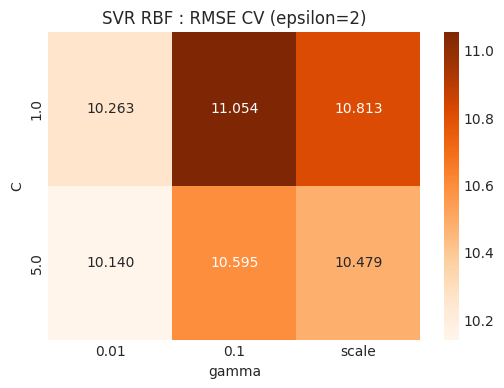

In [17]:
svr_rbf = svr_results[svr_results['param_model__kernel'] == 'rbf'].copy()
if not svr_rbf.empty:
    best_eps = svr_search.best_params_.get('model__epsilon', 1)
    svr_rbf_eps = svr_rbf[svr_rbf['param_model__epsilon'] == best_eps]
    svr_pivot = svr_rbf_eps.pivot_table(index='param_model__C', columns='param_model__gamma', values='mean_test_score')
    plt.figure(figsize=(6, 4))
    sns.heatmap(-svr_pivot, annot=True, fmt='.3f', cmap='Oranges')
    plt.title(f'SVR RBF : RMSE CV (epsilon={best_eps})')
    plt.xlabel('gamma')
    plt.ylabel('C')
    plt.show()

La comparaison entre noyaux `linear` et `rbf` reste instructive. Ici, la validation croisée montre que les meilleures performances du noyau `rbf` restent légèrement inférieures à celles du meilleur `SVR` retenu, qui est linéaire. Cela suggère que, pour prédire `Cholesterol_LDL`, une relation globale assez simple entre les variables explicatives et la cible capture déjà l'essentiel du signal. La heatmap du noyau `rbf` montre aussi que les performances varient selon `C` et `gamma`, ce qui confirme que ce noyau est plus flexible mais aussi plus sensible au réglage des hyperparamètres. Dans cette étude, cette flexibilité supplémentaire n'apporte pas de gain de généralisation suffisant, ce qui ne plaide pas en faveur d'une non-linéarité forte.


In [18]:
regression_models = {
    'kNN régression': knn_reg_search.best_estimator_,
    'SVR': svr_search.best_estimator_,
}

regression_results = []
for name, model in regression_models.items():
    y_pred = model.predict(Xr_test)
    regression_results.append({
        'Modèle': name,
        'RMSE': round(mean_squared_error(yr_test, y_pred) ** 0.5, 4),
        'MAE': round(mean_absolute_error(yr_test, y_pred), 4),
        'R2': round(r2_score(yr_test, y_pred), 4),
    })

regression_results = pd.DataFrame(regression_results).sort_values('RMSE')
regression_results

,Modèle,RMSE,MAE,R2
1,SVR,9.8470,7.8093,0.6932
0,kNN régression,11.4284,9.1079,0.5868


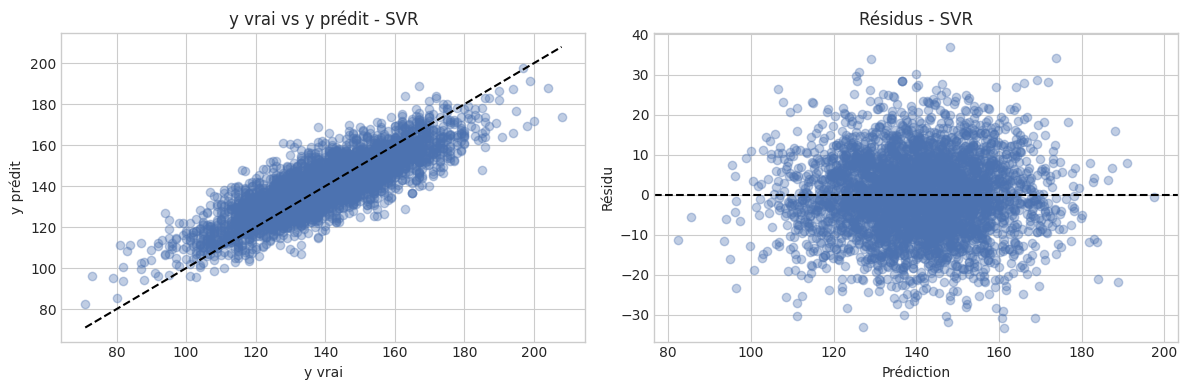

In [19]:
best_reg_name = regression_results.iloc[0]['Modèle']
best_reg = regression_models[best_reg_name]
y_pred_best_reg = best_reg.predict(Xr_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(yr_test, y_pred_best_reg, alpha=0.35)
axes[0].plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], color='black', linestyle='--')
axes[0].set_title(f'y vrai vs y prédit - {best_reg_name}')
axes[0].set_xlabel('y vrai')
axes[0].set_ylabel('y prédit')

residuals = yr_test - y_pred_best_reg
axes[1].scatter(y_pred_best_reg, residuals, alpha=0.35)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title(f'Résidus - {best_reg_name}')
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Résidu')

plt.tight_layout()
plt.show()

### Lecture des résultats de régression

Les performances sont évaluées sur le test final avec trois métriques complémentaires :
- la **RMSE**, qui pénalise fortement les grosses erreurs ;
- la **MAE**, plus robuste et plus facile à interpréter ;
- le **R²**, qui mesure la part de variance expliquée par le modèle.

L’interprétation dépend ensuite du modèle dominant :
- un **SVR linéaire** suggère qu’une relation relativement simple explique bien `Cholesterol_LDL` ;
- un **SVR RBF** ou un **kNN** traduit plutôt des relations plus locales ou non linéaires.

## 6. Comparaisons globales

On regroupe les résultats finaux sur le **jeu de test**, utilisé ici une seule fois, après le tuning. On peut alors comparer à la fois :
- la performance ;
- la stabilité suggérée par le type de modèle et ses hyperparamètres ;
- la simplicité d'interprétation ;
- la sensibilité au scaling ;
- la capacité à modéliser des relations non linéaires.

In [20]:
classification_summary = classification_results.copy()
classification_param_map = {
    'kNN classification': knn_clf_search.best_params_,
    'SVM classification': svc_search.best_params_,
}
classification_summary['Hyperparamètres retenus'] = classification_summary['Modèle'].map(classification_param_map)
classification_summary

,Modèle,Accuracy,Balanced accuracy,F1-score,ROC-AUC,Hyperparamètres retenus
1,SVM classification,0.7237,0.7120,0.6619,0.7937,"{'model__C': 1, 'model__kernel': 'linear'}"
0,kNN classification,0.6837,0.6619,0.5755,0.7387,"{'model__metric': 'manhattan', 'model__n_neigh..."


In [21]:
regression_summary = regression_results.copy()
regression_param_map = {
    'kNN régression': knn_reg_search.best_params_,
    'SVR': svr_search.best_params_,
}
regression_summary['Hyperparamètres retenus'] = regression_summary['Modèle'].map(regression_param_map)
regression_summary

,Modèle,RMSE,MAE,R2,Hyperparamètres retenus
1,SVR,9.8470,7.8093,0.6932,"{'model__C': 0.5, 'model__epsilon': 2, 'model_..."
0,kNN régression,11.4284,9.1079,0.5868,"{'model__metric': 'euclidean', 'model__n_neigh..."


### Analyse comparative

En **classification**, la comparaison principale porte sur la capacité à bien discriminer les deux classes sans s'adapter artificiellement au test. Le kNN apporte une lecture locale intuitive, alors que le SVM fournit une frontière globale plus directement reliée aux notions de marge et de régularisation.

En **régression**, le kNN modélise une moyenne locale, tandis que le SVR cherche une fonction régularisée, éventuellement non linéaire si un noyau RBF est retenu. Le choix entre ces modèles dépend donc autant de la performance que de la nature supposée de la relation entre les variables et le LDL.

## 7. Bilan final

### Meilleur modèle de classification

Le meilleur classifieur sur l’échantillon de test est le **SVM linéaire**. Il obtient la meilleure **balanced accuracy**, ainsi qu’un bon compromis entre `accuracy`, `F1-score` et `ROC-AUC`. Ce résultat suggère que, pour la prédiction de `Heart_Disease_Risk`, une frontière de décision globale relativement simple suffit déjà à bien séparer les deux classes.

### Meilleur modèle de régression

Le meilleur régresseur sur l’échantillon de test est le **SVR linéaire**. Il présente la **RMSE** la plus faible parmi les modèles comparés, ainsi qu’une **MAE** plus faible et un **R²** plus élevé que le `kNN` régression. Cela indique que, pour prédire `Cholesterol_LDL`, une relation globale assez régulière entre les variables explicatives et la cible semble mieux convenir qu’une méthode purement locale.

### Discussion biais / variance

Les résultats obtenus sont cohérents avec le compromis biais / variance vu en cours. Pour le `kNN`, des voisinages trop petits conduisent à un modèle très ajusté aux données d’entraînement, donc plus instable. À l’inverse, des valeurs plus grandes de `k` stabilisent les prédictions mais peuvent lisser excessivement la structure des données.  
Du côté des méthodes à marge, les meilleurs modèles retenus sont ici **linéaires** : cela signifie qu’une flexibilité plus forte, comme celle offerte par un noyau `RBF`, n’apporte pas de gain suffisant en validation croisée. On évite ainsi un surcroît de variance et un risque de surapprentissage inutile.

### Limites de l'analyse

Certains points restent limitants sur le projet :

- les performances dépendent du découpage `train/test`, même si le `random_state` fixé garantit la reproductibilité. Ici, il est doné dans l'enoncé donc on a pas pu modifier ce paramètre.

- seuls quelques modèle sont comparés, notre étude reste exhaustive.



In [22]:
best_clf_row = classification_summary.iloc[0]
best_reg_row = regression_summary.iloc[0]

bilan_final = pd.DataFrame([
    {
        'Tâche': 'Classification',
        'Meilleur modèle': best_clf_row['Modèle'],
        'Hyperparamètres retenus': best_clf_row['Hyperparamètres retenus'],
        'Performance finale test': {
            'Accuracy': best_clf_row['Accuracy'],
            'Balanced accuracy': best_clf_row['Balanced accuracy'],
            'F1-score': best_clf_row['F1-score'],
            'ROC-AUC': best_clf_row['ROC-AUC'],
        },
    },
    {
        'Tâche': 'Régression',
        'Meilleur modèle': best_reg_row['Modèle'],
        'Hyperparamètres retenus': best_reg_row['Hyperparamètres retenus'],
        'Performance finale test': {
            'RMSE': best_reg_row['RMSE'],
            'MAE': best_reg_row['MAE'],
            'R2': best_reg_row['R2'],
        },
    },
])

bilan_final

,Tâche,Meilleur modèle,Hyperparamètres retenus,Performance finale test
0,Classification,SVM classification,"{'model__C': 1, 'model__kernel': 'linear'}","{'Accuracy': 0.7237, 'Balanced accuracy': 0.71..."
1,Régression,SVR,"{'model__C': 0.5, 'model__epsilon': 2, 'model_...","{'RMSE': 9.847, 'MAE': 7.8093, 'R2': 0.6932}"


## 8. Conclusion

Dans ce notebook, on a comparé `kNN`, `SVM` et `SVR` sur deux problèmes différents : la classification du risque cardiaque et la régression du taux de `Cholesterol_LDL`. L'idée était aussi de garder une démarche propre d'un point de vue méthodologique, avec un choix des hyperparamètres par validation croisée sur le train, puis une évaluation finale sur le test.

Plusieurs points ressortent assez clairement. D'abord, le **scaling** est vraiment important pour ces méthodes, car elles reposent soit sur des distances, soit sur la géométrie de la séparation. Ensuite, le choix des hyperparamètres comme `k`, `C`, `gamma` ou `epsilon` joue directement sur le compromis biais/variance : un modèle trop flexible peut vite surajuster, alors qu'un modèle trop contraint risque de lisser excessivement les relations présentes dans les données.
Il est hyper important de trouver le bon compromis

On voit aussi qu'un noyau `RBF` n'est pas forcément meilleur qu'un modèle linéaire. Même s'il est plus flexible, il n'apporte pas ici de gain suffisant en généralisation. Dans notre cas, les meilleurs résultats sont obtenus avec un **SVM linéaire** pour la classification et  pour la régression, ce qui montre qu'une structure globale assez simple décrit déjà correctement les données.

Au final, cette étude permet de comparer des approches assez différentes, tout en restant dans un cadre cohérent avec le cours. Elle montre surtout qu'un modèle plus complexe n'est pas automatiquement meilleur, et qu'un bon réglage méthodologique compte autant que le choix du modèle lui-même.
